In [1]:
import sys
sys.path.insert(0, "../src/fg_removal_pipe")  # add Folder_2 path to search list
import diff_removal as bss
from Jybeam_2_K import TFromJyBeam
from power_spectrum import cyclindircal_powerspec
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np

base = '/home/ppxjf3/repos/Foreground_Removal_Pipeline/'

In [2]:
#open all fits images and make into numpy array

num = 26
init = 525
bss_data = np.zeros([1024,1024,num])
for ii in range(0,num):

    fits_path = base + 'data/ZW3_BSS_0'+str(init+ii)+'-image.fits'

    hdul = fits.open(fits_path)

    img = np.squeeze(hdul[0].data)
    bss_data[:,:,ii] = img
    hdul.info()
    hdul.close()

Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0525-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   


Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0526-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0527-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0528-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0529-image.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (1024, 1024, 1, 1)   float32   
Filename: /home/ppxjf3/repos/Foreground_Removal_Pipeline/data/ZW3_BSS_0530-image.fits
No.    Name      Ver    Ty

In [3]:
#convert to K from Jy/beam
nu = np.arange(158.5, 158.5+num*0.1, 0.1)
print(nu)
#beam size
bmaj = 0.0441365996677112
bmin = 0.032916727852457

bss_data_K = TFromJyBeam(bss_data, bmaj, bmin, nu)

[158.5 158.6 158.7 158.8 158.9 159.  159.1 159.2 159.3 159.4 159.5 159.6
 159.7 159.8 159.9 160.  160.1 160.2 160.3 160.4 160.5 160.6 160.7 160.8
 160.9 161. ]


#look at images in K and Jy/beam
for ii in range(0,num):
    plt.imshow(bss_data_K[:,:,ii])
    plt.colorbar(label='K')
    plt.show()
    plt.imshow(bss_data[:,:,ii])
    plt.colorbar(label='Jy/Beam')
    plt.show()

In [4]:
#cut to central 4 degrees (512 by 512)
i0 = 512//2
i1 = 1024 - (512//2)

#FastICA
mod_fICA, res_fICA = bss.fastica(bss_data_K[i0:i1,i0:i1,:], 4)

#GPR
#mod_GPR, res_GPR, res = bss.GPR(bss_data_K[i0:i1,i0:i1,:], nu)  

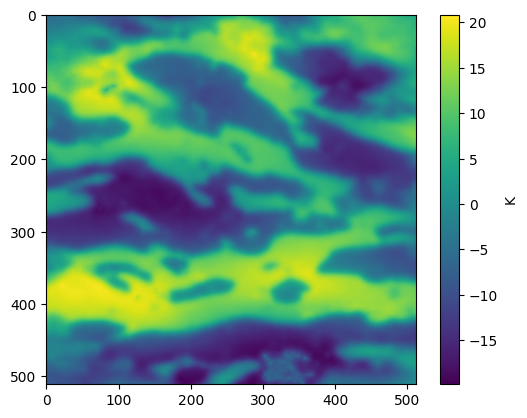

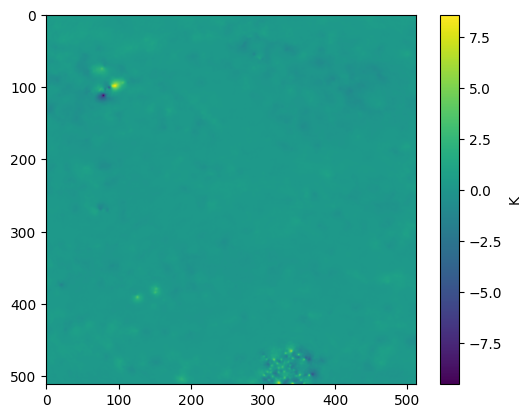

"plt.imshow(mod_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()\nplt.imshow(res_GPR[:,:,0])\nplt.colorbar(label='K')\nplt.show()\nplt.imshow(res[:,:,0])\nplt.colorbar(label='K')\nplt.show()"

In [5]:

plt.imshow(mod_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.figure()
plt.imshow(res_fICA[:,:,0])
plt.colorbar(label='K')
plt.show()

"""plt.imshow(mod_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res_GPR[:,:,0])
plt.colorbar(label='K')
plt.show()
plt.imshow(res[:,:,0])
plt.colorbar(label='K')
plt.show()"""

In [6]:
#get bin edges as defined by the data challenge
filename_kpar = "/home/ppxjf3/SKAO_DATA_CHALLENGE/bins_kpar.txt"
kpar_bins_skao = np.loadtxt(filename_kpar)

filename_kper = "/home/ppxjf3/SKAO_DATA_CHALLENGE/bins_kper.txt"
kper_bins_skao = np.loadtxt(filename_kper)

kbins_skao = [kper_bins_skao, kpar_bins_skao] #bin centers

dkper = kper_bins_skao[1] - kper_bins_skao[0]
dkpar = kpar_bins_skao[1] - kpar_bins_skao[0]
kper_edges_skao = np.arange(len(kper_bins_skao)+1) * dkper + (kper_bins_skao[0] - 0.5 * dkper)
kpar_edges_skao = np.arange(len(kpar_bins_skao)+1) * dkpar + (kpar_bins_skao[0] - 0.5 * dkpar)

kbins_edges = [kper_edges_skao, kpar_edges_skao] # bin edges

In [10]:
import tools21cm as t2c
from scipy import interpolate
import matplotlib.colors as colors

#make power spectra FastICA
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

pp, kper, kpar= t2c.power_spectrum_2d(res_fICA,  binning = 'linear', kbins=kbins_edges, return_modes=False)


#normalise to dimensionless power spectrum
for ii in range(0,len(kper)):
    for jj in range(0,len(kpar)):
        pp[ii,jj] = (pp[ii,jj]*np.sqrt(kper[ii]**2+kpar[jj]**2)**3)/(2*np.pi**2)
print(pp)
fp = interpolate.interp2d(kper, kpar, pp.T, kind='linear')
CC = fp(kper,kpar)
print(CC)
norm = colors.LogNorm(vmin=CC[np.isfinite(CC)].min(), vmax=CC[np.isfinite(CC)].max()) if plotting_scale['z']=='log' else None 

#kper, kpar, CC, norm = cyclindircal_powerspec(res_fICA, kbins_edges) #, nu, 4.55)


pcm = plt.pcolormesh(kper, kpar, CC, norm=norm, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()

[[0.0084721  0.02589536 0.06383272 0.13095836 0.14938928        nan
         nan        nan        nan        nan]
 [0.01113253 0.01764356 0.03054926 0.0657654  0.0434723         nan
         nan        nan        nan        nan]
 [0.02299521 0.02471064 0.0404827  0.06321168 0.06166995        nan
         nan        nan        nan        nan]
 [0.03792493 0.03800763 0.05303298 0.07322566 0.07534           nan
         nan        nan        nan        nan]
 [0.05847091 0.05276968 0.0754087  0.08707142 0.10388174        nan
         nan        nan        nan        nan]
 [0.084838   0.07187355 0.09580742 0.10779559 0.10857447        nan
         nan        nan        nan        nan]
 [0.09751465 0.08161812 0.09936029 0.10683132 0.10435801        nan
         nan        nan        nan        nan]
 [0.10030922 0.09301902 0.09907884 0.09687192 0.1152835         nan
         nan        nan        nan        nan]
 [0.10373829 0.09540372 0.09396521 0.08508182 0.09795073        nan
         nan

ValueError: zero-size array to reduction operation minimum which has no identity

In [ ]:
#compare to the truth!!

In [ ]:
#make power spectra GPR
plotting_scale={'x': 'log', 'y': 'log', 'z': 'log'}

kper, kpar, CC, norm = cyclindircal_powerspec()

pcm = plt.pcolormesh(kper, kpar, CC, norm=norm, cmap='inferno')
cbar= plt.colorbar(pcm)
cbar.set_label(r'$\Delta_{\rm 3D}^2 (k_{\parallel}, k_{\perp}) /\rm mK^2 $', size=16) 
plt.xlabel(r'$k_{\perp}/ \rm Mpc^{-1}$', fontsize = 14)
plt.ylabel(r'$k_{\parallel} /\rm Mpc^{-1}$', fontsize = 14)
plt.xscale(plotting_scale['x'])
plt.yscale(plotting_scale['y'])
plt.show()